# v4 Phase Visualization

Notebook trực quan hóa được tách thành 3 phase tương ứng với pipeline mới:

1. Tiền xử lý
2. Trích chọn đặc trưng
3. Phân tích mô hình

Ở thời điểm hiện tại notebook sẽ render đầy đủ phase preprocessing từ output v4 mới. Hai phase sau sẽ tự kiểm tra artifact v4 và skip sạch nếu chưa có.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

from IPython.display import Markdown, display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.visualization import (
    render_feature_phase_report,
    render_model_phase_report,
)

PROCESSED_ROOT = PROJECT_ROOT / 'data' / 'processed_v4_rgb248_r4_exact'
MANIFEST_PATH = PROCESSED_ROOT / 'manifest.csv'
FEATURES_PATH = PROJECT_ROOT / 'features' / 'features_dataset_v4_rgb248_r4_exact.csv'
MODEL_ROOT = PROJECT_ROOT / 'models' / '04_artifacts_v4_rgb248_r4_exact'
VIS_ROOT = PROJECT_ROOT / 'audit_output' / 'validation' / 'spec_v4_20260319' / 'visualization_v4_rgb248_r4_exact'
PRE_VIS = VIS_ROOT / 'preprocessing'
FEATURE_VIS = VIS_ROOT / 'feature_extraction'
MODEL_VIS = VIS_ROOT / 'model_analysis'

PLOT_ROOT = PRE_VIS / 'plots'
PLOT_ROOT.mkdir(parents=True, exist_ok=True)


## Phase 1 — Tiền xử lý

In [2]:
manifest = pd.read_csv(MANIFEST_PATH)
manifest['support'] = pd.to_numeric(manifest['support'], errors='coerce')
status_by_label = manifest.groupby(['label', 'status']).size().unstack(fill_value=0)
pre_summary = {
    'n_total': int(len(manifest)),
    'status_counts': manifest['status'].value_counts().to_dict(),
    'status_by_label': status_by_label.to_dict(),
}
pre_summary

{'n_total': 87971,
 'status_counts': {'ACCEPTED': 85615,
  'LOW_SUPPORT': 1573,
  'UNSUPPORTED_INPUT': 783},
 'status_by_label': {'ACCEPTED': {'ai': 43992, 'nature': 41623},
  'LOW_SUPPORT': {'ai': 0, 'nature': 1573},
  'UNSUPPORTED_INPUT': {'ai': 0, 'nature': 783}}}

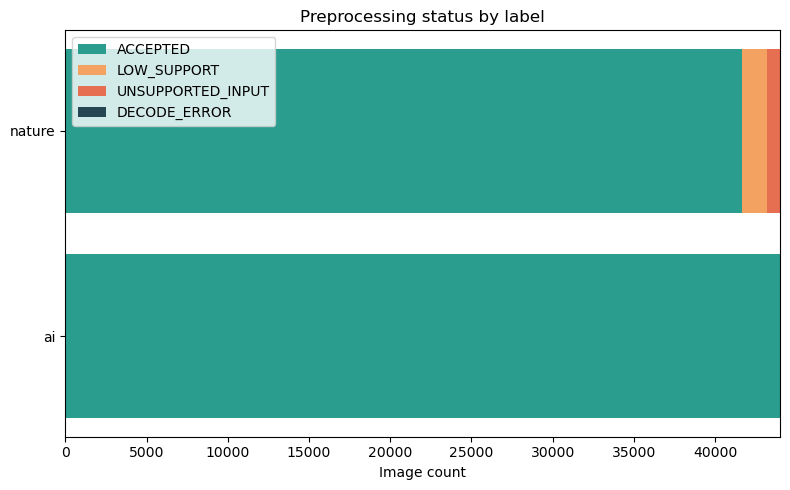

In [3]:
status_order = ['ACCEPTED', 'LOW_SUPPORT', 'UNSUPPORTED_INPUT', 'DECODE_ERROR']
status_colors = {'ACCEPTED': '#2a9d8f', 'LOW_SUPPORT': '#f4a261', 'UNSUPPORTED_INPUT': '#e76f51', 'DECODE_ERROR': '#264653'}
fig, ax = plt.subplots(figsize=(8, 5))
table = status_by_label.reindex(columns=status_order, fill_value=0)
left = np.zeros(len(table), dtype=float)
y = np.arange(len(table))
for status in status_order:
    values = table[status].to_numpy(dtype=float)
    ax.barh(y, values, left=left, color=status_colors[status], label=status)
    left += values
ax.set_yticks(y)
ax.set_yticklabels(table.index.tolist())
ax.set_xlabel('Image count')
ax.set_title('Preprocessing status by label')
ax.legend(loc='best')
fig.tight_layout()
fig.savefig(PLOT_ROOT / 'status_by_label.png', dpi=160)
plt.show()

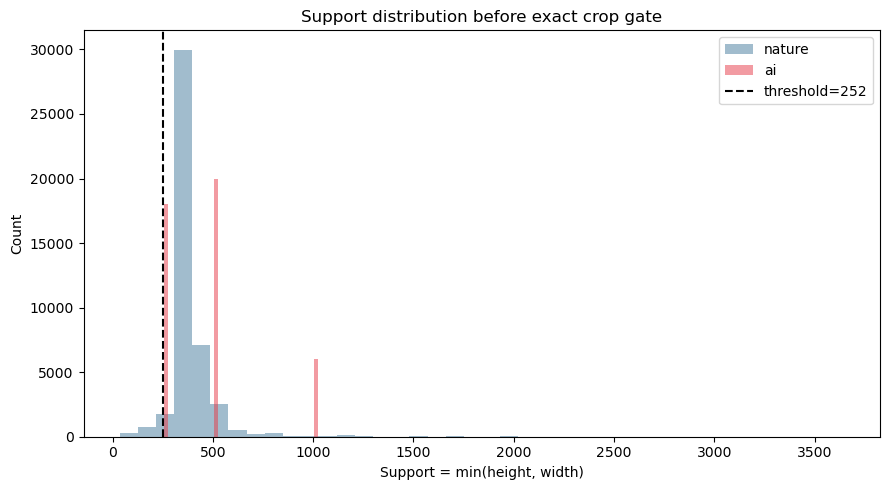

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for label, color in [('nature', '#457b9d'), ('ai', '#e63946')]:
    values = manifest.loc[manifest['label'] == label, 'support'].dropna().to_numpy(dtype=float)
    if values.size:
        ax.hist(values, bins=40, alpha=0.5, label=label, color=color)
ax.axvline(252, color='black', linestyle='--', linewidth=1.5, label='threshold=252')
ax.set_xlabel('Support = min(height, width)')
ax.set_ylabel('Count')
ax.set_title('Support distribution before exact crop gate')
ax.legend(loc='best')
fig.tight_layout()
fig.savefig(PLOT_ROOT / 'support_distribution.png', dpi=160)
plt.show()

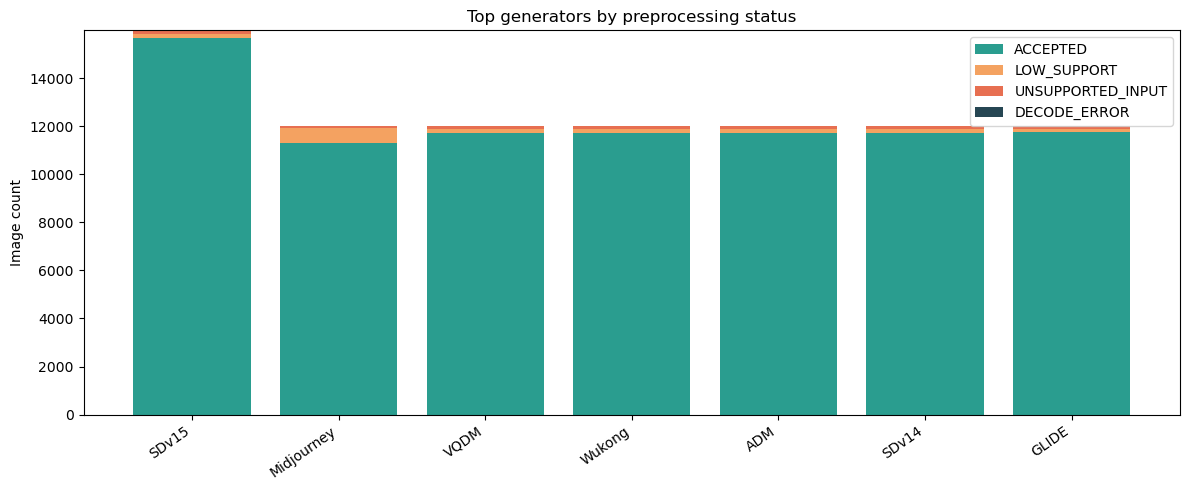

In [5]:
gen_table = manifest.groupby(['generator', 'status']).size().unstack(fill_value=0).reindex(columns=status_order, fill_value=0)
gen_table = gen_table.loc[gen_table.sum(axis=1).sort_values(ascending=False).head(12).index]
fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(gen_table), dtype=float)
x = np.arange(len(gen_table))
for status in status_order:
    values = gen_table[status].to_numpy(dtype=float)
    ax.bar(x, values, bottom=bottom, color=status_colors[status], label=status)
    bottom += values
ax.set_xticks(x)
ax.set_xticklabels(gen_table.index.tolist(), rotation=35, ha='right')
ax.set_ylabel('Image count')
ax.set_title('Top generators by preprocessing status')
ax.legend(loc='best')
fig.tight_layout()
fig.savefig(PLOT_ROOT / 'status_by_generator.png', dpi=160)
plt.show()

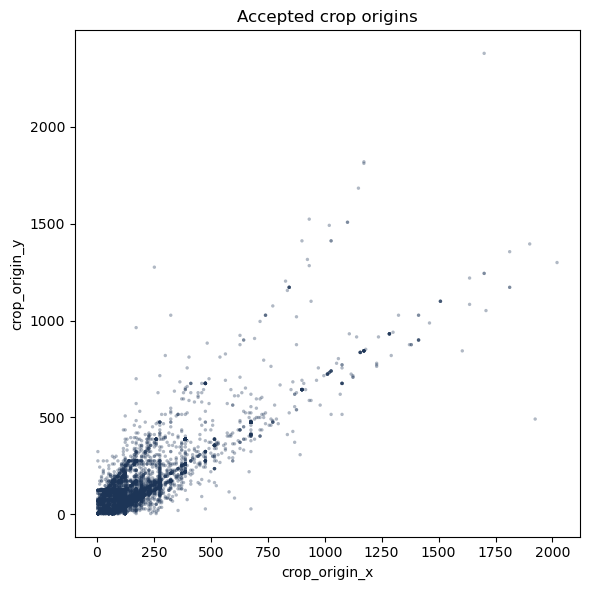

In [6]:
accepted = manifest.loc[(manifest['status'] == 'ACCEPTED') & (manifest['saved_patch'] == True)].copy()
accepted[['crop_origin_x', 'crop_origin_y']] = accepted[['crop_origin_x', 'crop_origin_y']].apply(pd.to_numeric, errors='coerce')
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(accepted['crop_origin_x'], accepted['crop_origin_y'], s=6, alpha=0.35, color='#1d3557', edgecolors='none')
ax.set_xlabel('crop_origin_x')
ax.set_ylabel('crop_origin_y')
ax.set_title('Accepted crop origins')
fig.tight_layout()
fig.savefig(PLOT_ROOT / 'crop_origin_scatter.png', dpi=160)
plt.show()

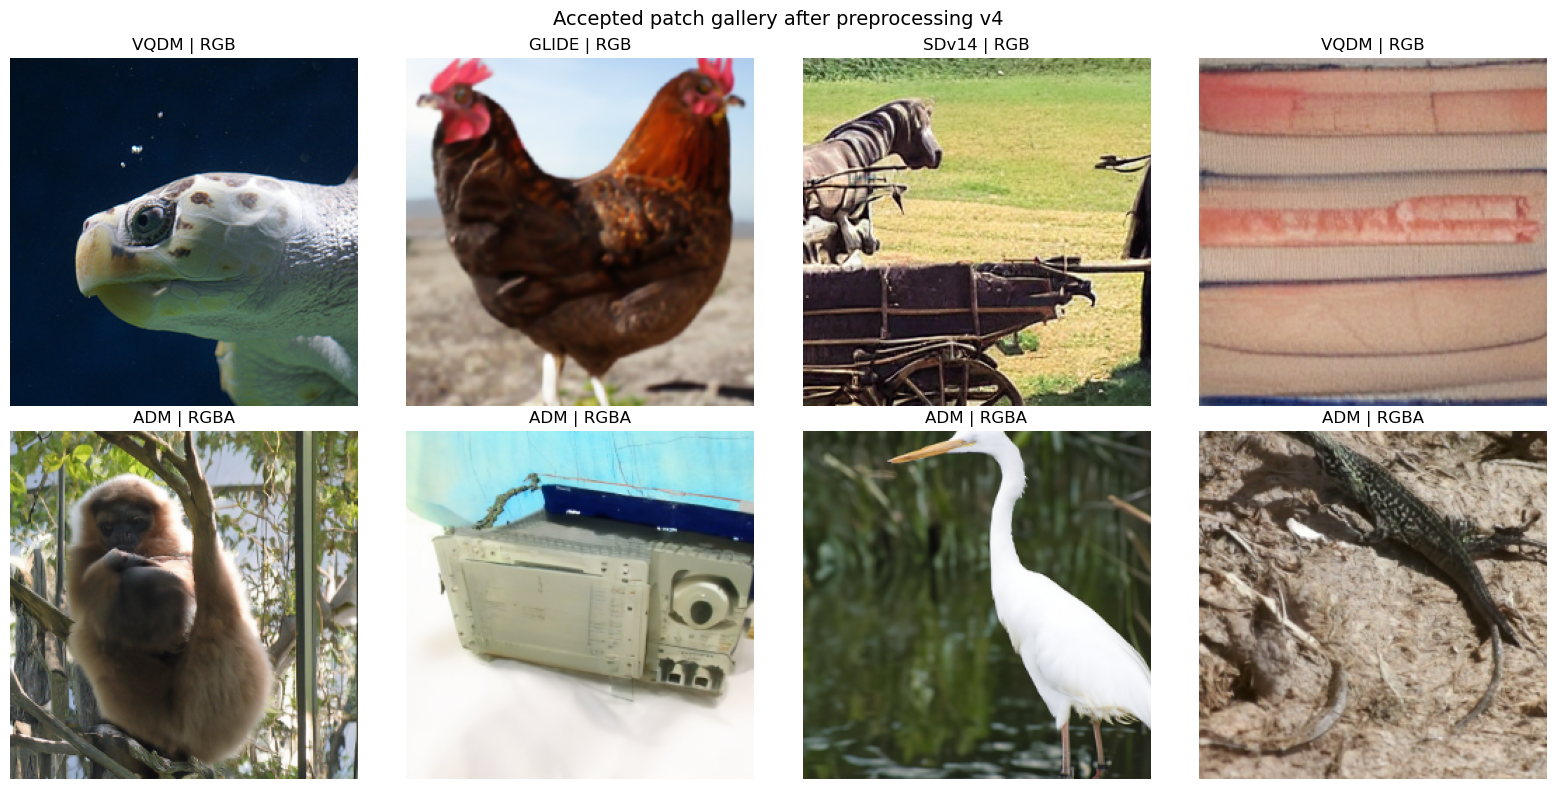

In [7]:
gallery_parts = []
for mode in ['RGB', 'RGBA']:
    subset = accepted.loc[accepted['input_mode'] == mode]
    if not subset.empty:
        gallery_parts.append(subset.sample(n=min(4, len(subset)), random_state=42))
gallery = pd.concat(gallery_parts, ignore_index=True) if gallery_parts else accepted.sample(n=min(8, len(accepted)), random_state=42)
n = len(gallery)
cols = min(4, n)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.atleast_1d(axes).reshape(rows, cols)
for ax in axes.flat:
    ax.axis('off')
for ax, (_, row) in zip(axes.flat, gallery.iterrows()):
    patch = np.load(row['output_path'])
    ax.imshow(patch)
    ax.set_title(f"{row['generator']} | {row['input_mode']}")
    ax.axis('off')
fig.suptitle('Accepted patch gallery after preprocessing v4', fontsize=14)
fig.tight_layout()
fig.savefig(PLOT_ROOT / 'patch_gallery.png', dpi=160)
plt.show()

## Phase 2 — Trích chọn đặc trưng

In [8]:
feature_summary = render_feature_phase_report(FEATURES_PATH, FEATURE_VIS)
feature_summary

{'available': False,
 'reason': 'missing feature dataset: C:\\Users\\USER\\Desktop\\ai_detector_img\\features\\features_dataset_v4_rgb248_r4_exact.csv'}

## Phase 3 — Phân tích mô hình

In [9]:
model_summary = render_model_phase_report(MODEL_ROOT, MODEL_VIS)
model_summary

{'available': False,
 'reason': 'missing evaluation_metrics.csv under C:\\Users\\USER\\Desktop\\ai_detector_img\\models\\04_artifacts_v4_rgb248_r4_exact'}